In [1]:
import torch
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F

import argparse
import sys
import os
import torch
from tqdm import tqdm 
import importlib
from config_urg import Config
# sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath(__file__)))) # only work in py
import os, sys

# 获取当前 notebook 文件所在的目录
current_dir = os.getcwd()

# 加到 sys.path
sys.path.append(os.path.dirname(os.path.dirname(current_dir)))


from modules.dataloaders import MyDataLoader
from modules.tokenizers import Tokenizer
from modules.metrics import compute_scores

In [5]:
current_dir

'/home/chenzhw/ultrasound_report_gen/US-Report-Gen/KMVE_RG'

In [6]:
base_dir = os.path.dirname(os.path.dirname(os.getcwd()))

In [2]:
def denormalize(tensor, mean, std):
    """
    反标准化一个 shape 为 [B, C, H, W] 或 [C, H, W] 的 Tensor。
    """
    mean = torch.tensor(mean).view(1, -1, 1, 1)
    std = torch.tensor(std).view(1, -1, 1, 1)
    return tensor * std + mean

In [3]:
batch_idx = 0
images_idx_in_batch = 2

attns = torch.load(f'/home/chenzhw/ultrasound_report_gen/US-Report-Gen/tracker/batch_{batch_idx}/attn.pt')
past_values = torch.load(f'/home/chenzhw/ultrasound_report_gen/US-Report-Gen/tracker/batch_{batch_idx}/past_values.pt')
source = torch.load(f'/home/chenzhw/ultrasound_report_gen/US-Report-Gen/tracker/batch_{batch_idx}/source.pt')

In [ ]:
attns

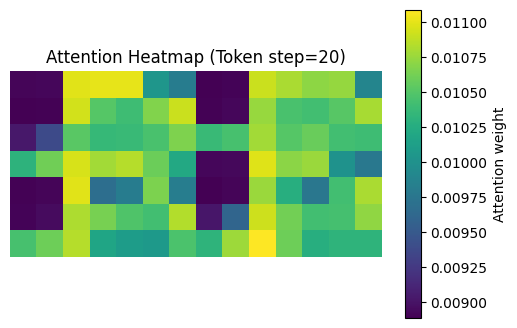

In [22]:
step = 20
index = 12
attns[(30,8,step,98)][index,:].shape # 8, step, 98
attns[(30,8,step,98)][index,:].mean(dim=0).shape # step, 98 
attn = attns[(30,8,step,98)][index,:].mean(dim=0)[step-1]
attn = attn.reshape(7, 14)
attn.shape # 7, 14

import matplotlib.pyplot as plt

# 假设你已经得到了 attn: shape (7, 14)
plt.figure(figsize=(6, 4))
plt.imshow(attn, interpolation='nearest')
plt.title(f"Attention Heatmap (Token step={step})")
plt.axis('off')
plt.colorbar(label='Attention weight')
plt.show()

In [24]:
attn.shape

torch.Size([7, 14])

In [29]:
attn_color_rgb.shape

(98, 1, 3)

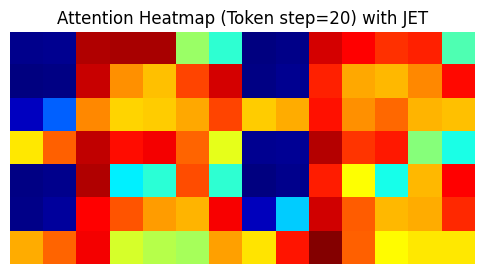

In [30]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 假设 attn 是 torch.Tensor，形状为 (7, 14)
attn_np = attn.cpu().numpy() if isinstance(attn, torch.Tensor) else attn

# Normalize to [0, 255]
attn_min, attn_max = attn_np.min(), attn_np.max()
attn_norm = (attn_np - attn_min) / (attn_max - attn_min + 1e-8)  # 避免除以 0
attn_uint8 = (attn_norm * 255).astype(np.uint8)  # shape: (7, 14)

# Apply OpenCV JET colormap
attn_color = cv2.applyColorMap(attn_uint8, cv2.COLORMAP_JET)  # shape: (7, 14, 3)

# OpenCV 使用 BGR，转换为 RGB 以供 matplotlib 显示
attn_color_rgb = cv2.cvtColor(attn_color, cv2.COLOR_BGR2RGB)

# 显示彩色 attention 热力图
plt.figure(figsize=(6, 4))
plt.imshow(attn_color_rgb)
plt.title(f"Attention Heatmap (Token step={step}) with JET")
plt.axis('off')
plt.show()


TypeError: Invalid shape (98,) for image data

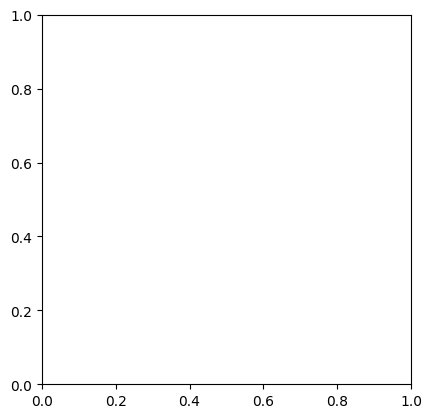

In [26]:
plt.imshow(attn_img)

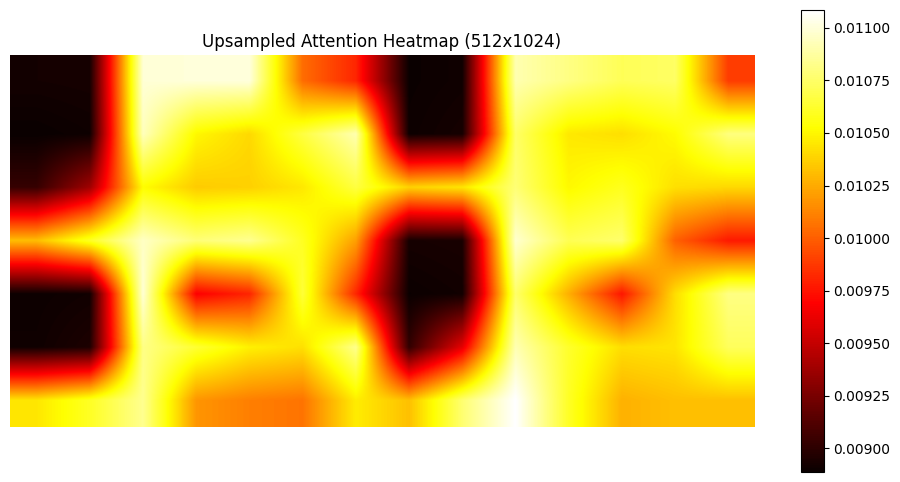

In [6]:
attn = attn.squeeze()  # 先清理可能多余的维度

# 转为 (1, 1, 7, 14)
attn = attn.unsqueeze(0).unsqueeze(0)  # 变成 (N, C, H, W)

# 插值到 (512, 1024)
attn_up = torch.nn.functional.interpolate(attn, size=(512, 1024), mode='bilinear', align_corners=False)

# 还原为 2D 图像
attn_up = attn_up.squeeze().numpy()

# 可视化
plt.figure(figsize=(12, 6))
plt.imshow(attn_up, cmap='hot')
plt.axis('off')
plt.title("Upsampled Attention Heatmap (512x1024)")
plt.colorbar()
plt.show()

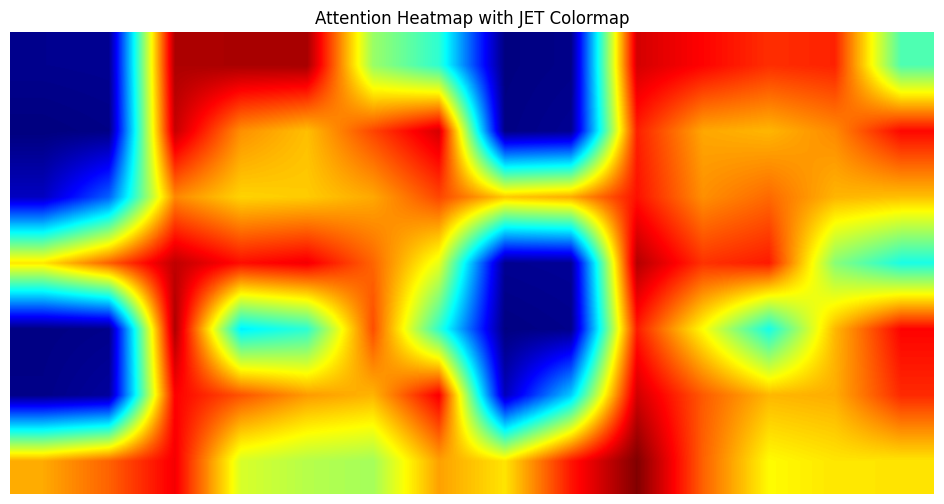

In [15]:
import cv2
import numpy as np
attn_uint8 = np.uint8(255 * (attn_up - attn_up.min()) / (attn_up.max() - attn_up.min()))
attn_color = cv2.applyColorMap(attn_uint8, cv2.COLORMAP_JET)

attn_color_rgb = cv2.cvtColor(attn_color, cv2.COLOR_BGR2RGB)

# 显示热力图
plt.figure(figsize=(12, 6))
plt.imshow(attn_color_rgb)
plt.axis('off')
plt.title("Attention Heatmap with JET Colormap")
plt.show()

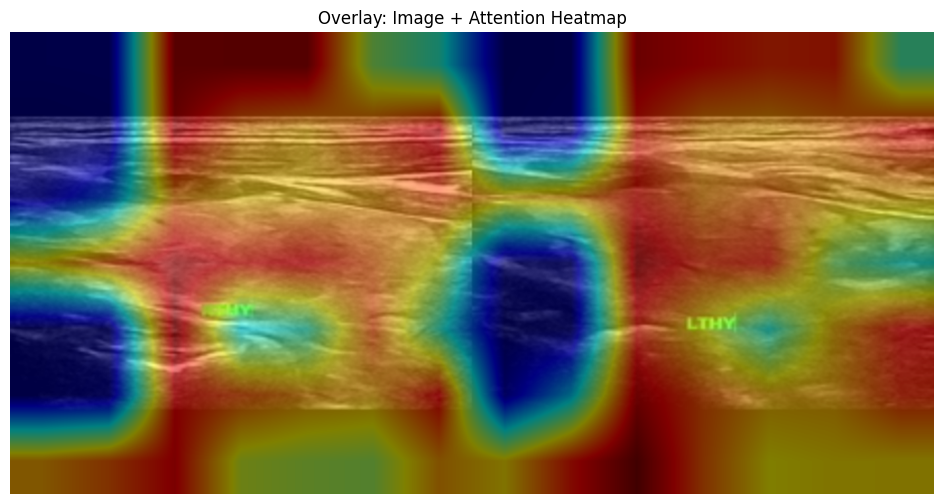

In [16]:

original_img = F.to_pil_image(concatenated).resize((1024, 512))  # 注意大小需匹配
original_np = np.array(original_img)

# 混合热力图和原图（0.5 可调）
overlay = cv2.addWeighted(original_np, 0.5, attn_color_rgb, 0.5, 0)

# 显示叠加图
plt.figure(figsize=(12, 6))
plt.imshow(overlay)
plt.axis('off')
plt.title("Overlay: Image + Attention Heatmap")
plt.show()

In [8]:
for key in attns.keys(): print(key)

(30, 8, 1, 98)
(30, 8, 2, 98)
(30, 8, 3, 98)
(30, 8, 4, 98)
(30, 8, 5, 98)
(30, 8, 6, 98)
(30, 8, 7, 98)
(30, 8, 8, 98)
(30, 8, 9, 98)
(30, 8, 10, 98)
(30, 8, 11, 98)
(30, 8, 12, 98)
(30, 8, 13, 98)
(30, 8, 14, 98)
(30, 8, 15, 98)
(30, 8, 16, 98)
(30, 8, 17, 98)
(30, 8, 18, 98)
(30, 8, 19, 98)
(30, 8, 20, 98)
(30, 8, 21, 98)
(30, 8, 22, 98)
(30, 8, 23, 98)
(30, 8, 24, 98)
(30, 8, 25, 98)
(30, 8, 26, 98)
(30, 8, 27, 98)
(30, 8, 28, 98)
(30, 8, 29, 98)
(30, 8, 30, 98)
(30, 8, 31, 98)
(30, 8, 32, 98)
(30, 8, 33, 98)
(30, 8, 34, 98)
(30, 8, 35, 98)
(30, 8, 36, 98)
(30, 8, 37, 98)
(30, 8, 38, 98)
(30, 8, 39, 98)
(30, 8, 40, 98)
(30, 8, 41, 98)
(30, 8, 42, 98)
(30, 8, 43, 98)
(30, 8, 44, 98)
(30, 8, 45, 98)
(30, 8, 46, 98)
(30, 8, 47, 98)
(30, 8, 48, 98)
(30, 8, 49, 98)
(30, 8, 50, 98)
(30, 8, 51, 98)
(30, 8, 52, 98)
(30, 8, 53, 98)
(30, 8, 54, 98)
(30, 8, 55, 98)
(30, 8, 56, 98)
(30, 8, 57, 98)
(30, 8, 58, 98)
(30, 8, 59, 98)
(30, 8, 60, 98)
(30, 8, 61, 98)
(30, 8, 62, 98)
(30, 8, 63, 98)
(

In [9]:
assert len(attns) == len(past_values)
print(source.keys())

dict_keys(['batch_idx', 'images_id', 'images', 'cap_lens', 'reports_ids', 'reports_masks', 'mesh_label', 'cmd_args'])


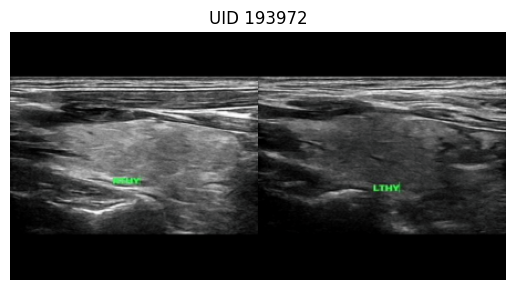

In [13]:
images = source['images'][images_idx_in_batch]  

images_denorm = denormalize(images, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))

img1 = images_denorm[0].clamp(0, 1)
img2 = images_denorm[1].clamp(0, 1)

# 水平拼接：确保尺寸匹配（都是 [3, 224, 224]）
concatenated = torch.cat([img1, img2], dim=2)  # dim=2 是宽度方向

# 显示
plt.imshow(F.to_pil_image(concatenated))

plt.axis('off')
uid = source['images_id'][images_idx_in_batch]
plt.title(f'UID {uid}')
plt.show()

In [11]:
source['cmd_args']['ckpt']

'US-Report-Gen/Result/TF_organ_balence_sampler-4090/Models/all_best.pth'

In [5]:

config_args = Config(**source['cmd_args'])
def seed_everything(seed: int):
        if isinstance(seed, str):
            seed = int(seed)
        import random, os
        import numpy as np
        import torch

        random.seed(seed)
        os.environ['PYTHONHASHSEED'] = str(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.backends.mps.is_available():
            torch.mps.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(config_args.seed)
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cpu'
model_module = importlib.import_module(f'KMVE_RG.models.{source["cmd_args"]["model"]}', )
model_class = getattr(model_module, source["cmd_args"]["model"])

tokenizer = Tokenizer(config_args)
model = model_class(config_args, tokenizer)
model = model.to(device)
model.eval()
base_dir = os.path.dirname(os.path.dirname(os.getcwd()))
ckpt = f'{base_dir}/{source["cmd_args"]["ckpt"]}'
checkpoint = torch.load(ckpt)
model.load_state_dict(checkpoint['state_dict'])

Building prefix dict from the default dictionary ...
Loading model from cache /tmp/jieba.cache
Loading model cost 0.243 seconds.
Prefix dict has been built successfully.


reading ann from /home/chenzhw/ultrasound_report_gen/USData/all.json
 len(self.tokens) = 1152


/home/chenzhw/miniconda3/envs/NassirUSReportGen/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/chenzhw/miniconda3/envs/NassirUSReportGen/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


first init the imagenet pretrained!
vocabulary size: 1153


<All keys matched successfully>

In [9]:
class UIDCaption:
    '''一个 uid 对应的生成情况'''
    def __init__(self, batch_idx):

        attns = torch.load(f'/home/chenzhw/ultrasound_report_gen/US-Report-Gen/tracker/batch_{batch_idx}/attn.pt')
        past_values = torch.load(f'/home/chenzhw/ultrasound_report_gen/US-Report-Gen/tracker/batch_{batch_idx}/past_values.pt')
        source = torch.load(f'/home/chenzhw/ultrasound_report_gen/US-Report-Gen/tracker/batch_{batch_idx}/source.pt')
        self.source = source
        self.attns = attns
        self.past_values = past_values
        
        
        self.ckpt = self.source['cmd_args']['ckpt']
        self.model = self.load_model(self.source)
    
    def get_images_tensor(self, image_index_in_batch):
        return self.source['images'][image_index_in_batch]
    
    def get_images_denrom(self, images_index_in_batch):
        images = self.source['images'][images_index_in_batch]  

        images_denorm = denormalize(images, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
        return images_denorm

    def load_model(self,source):
        config_args = Config(**source['cmd_args'])
        def seed_everything(seed: int):
            if isinstance(seed, str):
                seed = int(seed)
            import random, os
            import numpy as np
            import torch

            random.seed(seed)
            os.environ['PYTHONHASHSEED'] = str(seed)
            np.random.seed(seed)
            torch.manual_seed(seed)
            if torch.backends.mps.is_available():
                torch.mps.manual_seed(seed)
            torch.cuda.manual_seed(seed)
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False

        seed_everything(config_args.seed)
        device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cpu'
        model_module = importlib.import_module(f'KMVE_RG.models.{source["cmd_args"]["model"]}', )
        model_class = getattr(model_module, source["cmd_args"]["model"])

        tokenizer = Tokenizer(config_args)
        model = model_class(config_args, tokenizer)
        model = model.to(device)
        model.eval()
        base_dir = os.path.dirname(os.path.dirname(os.getcwd()))
        ckpt = f'{base_dir}/{source["cmd_args"]["ckpt"]}'
        checkpoint = torch.load(ckpt)
        model.load_state_dict(checkpoint['state_dict'])
        return model
    
    def show_images(self, index):
        images_denorm = self.get_images_denrom(index)
        img1 = images_denorm[0].clamp(0, 1)
        img2 = images_denorm[1].clamp(0, 1)

        # 水平拼接：确保尺寸匹配（都是 [3, 224, 224]）
        concatenated = torch.cat([img1, img2], dim=2)  # dim=2 是宽度方向

        # 显示
        plt.imshow(F.to_pil_image(concatenated))

        plt.axis('off')
        uid = source['images_id'][index]
        plt.title(f'UID {uid}')
        plt.show()


    def show_step_attention(self, index: int, step: int, pick=None):
        ''' supported pick: sum, min, max, mean, head i'''
        attn = self.attns[(30,8,step,98)][2,:] # shape [8, STEP, 98]

        pass 
    # todo, 展示第 index 个图片在第 step 步的时候，图像热力图以及根据这个热力图得到的结果。展示为热力图+title为预测的词

    def step(self, history, attn):
        pass
    # todo, 传入新的attention矩阵，计算往前推进一步的结果，并更新history

    def alter_attn(self, attn):
        pass
    # todo 人为修改attn

In [10]:
uidcaption = UIDCaption(0)

Building prefix dict from the default dictionary ...
Loading model from cache /tmp/jieba.cache
Loading model cost 0.263 seconds.
Prefix dict has been built successfully.


reading ann from /home/chenzhw/ultrasound_report_gen/USData/all.json
 len(self.tokens) = 1152


/home/chenzhw/miniconda3/envs/NassirUSReportGen/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/chenzhw/miniconda3/envs/NassirUSReportGen/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


first init the imagenet pretrained!
vocabulary size: 1153


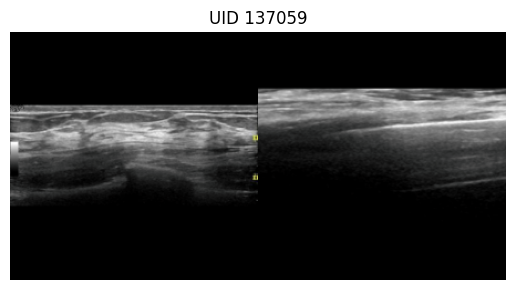

In [15]:
uidcaption.show_images(7)

In [ ]:
# read model from ckpt
# define fn(current_state)->new_state

In [17]:
source['batch_idx'] == idx

True

In [19]:
len(source['images_id'])

30

In [20]:
source['images'].shape

torch.Size([30, 2, 3, 224, 224])

In [22]:
len(source['cap_lens'])

30